# Image Preprocessing Pipeline

Pipeline xử lý ảnh cho Vietnamese OCR:
1. **Grayscale conversion** - Chuyển sang ảnh xám
2. **Min-Max normalization** - Chuẩn hóa pixel values về [0, 1]
3. **Resize** - Chuẩn hóa kích thước ảnh

In [5]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import json
from tqdm import tqdm
import pandas as pd
from datasets import Dataset, DatasetDict
import cv2

## Load Dataset from Disk

In [6]:
from datasets import load_from_disk

# Load the saved dataset
dataset = load_from_disk("../data/hwdb_word_dataset")

print("Dataset structure:")
print(dataset)
print(f"\nTotal samples: {len(dataset)}")
print(f"\nFeatures: {dataset.features}")
print(f"\nFirst sample:")
print(f"  - Label: {dataset[0]['text']}")
print(f"  - Image shape: {dataset[0]['image'].size}")

Dataset structure:
Dataset({
    features: ['image', 'text'],
    num_rows: 110488
})

Total samples: 110488

Features: {'image': Image(mode=None, decode=True), 'text': Value('string')}

First sample:
  - Label: Số
  - Image shape: (128, 96)


## Preprocessing Functions

In [7]:
def preprocess_image(image, target_size=(128, 32), show_steps=False):
    """
    Preprocess image with:
    1. Grayscale conversion
    2. Min-Max normalization
    3. Resize to target size

    Args:
        image: PIL Image or numpy array
        target_size: (width, height) tuple
        show_steps: Whether to visualize preprocessing steps

    Returns:
        Preprocessed image as numpy array
    """
    # Convert PIL to numpy if needed
    if isinstance(image, Image.Image):
        img = np.array(image)
    else:
        img = image

    original = img.copy()

    # Step 1: Convert to grayscale if needed
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img

    # Step 2: Min-Max normalization (scale to [0, 1])
    normalized = (gray - gray.min()) / (gray.max() - gray.min() + 1e-8)

    # Step 3: Resize to target size
    resized = cv2.resize(normalized, target_size, interpolation=cv2.INTER_AREA)

    if show_steps:
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))

        if len(original.shape) == 3:
            axes[0].imshow(original)
        else:
            axes[0].imshow(original, cmap="gray")
        axes[0].set_title(
            f"Original\n{original.shape[:2][::-1] if len(original.shape) >= 2 else original.shape}"
        )
        axes[0].axis("off")

        axes[1].imshow(gray, cmap="gray")
        axes[1].set_title(f"Grayscale\n{gray.shape[::-1]}")
        axes[1].axis("off")

        axes[2].imshow(normalized, cmap="gray", vmin=0, vmax=1)
        axes[2].set_title(
            f"Normalized\nmin={normalized.min():.2f}, max={normalized.max():.2f}"
        )
        axes[2].axis("off")

        axes[3].imshow(resized, cmap="gray", vmin=0, vmax=1)
        axes[3].set_title(f"Resized\n{target_size}")
        axes[3].axis("off")

        plt.tight_layout()
        plt.show()

    return resized

## Test Preprocessing on Sample Images

Testing preprocessing on random samples...


Label: 'cuộc'


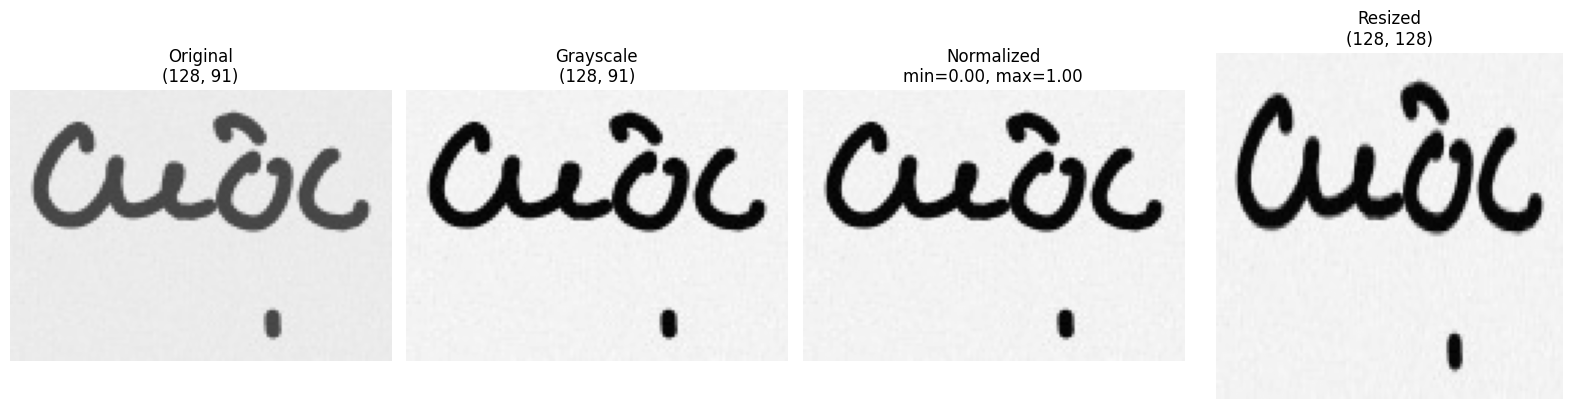


Label: 'xe'


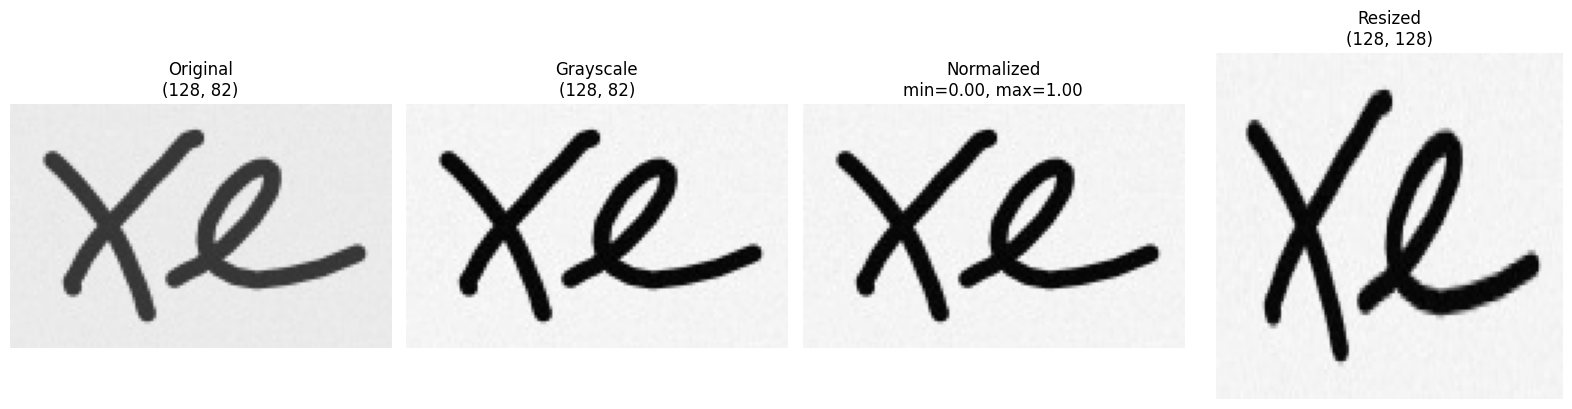


Label: 'lực'


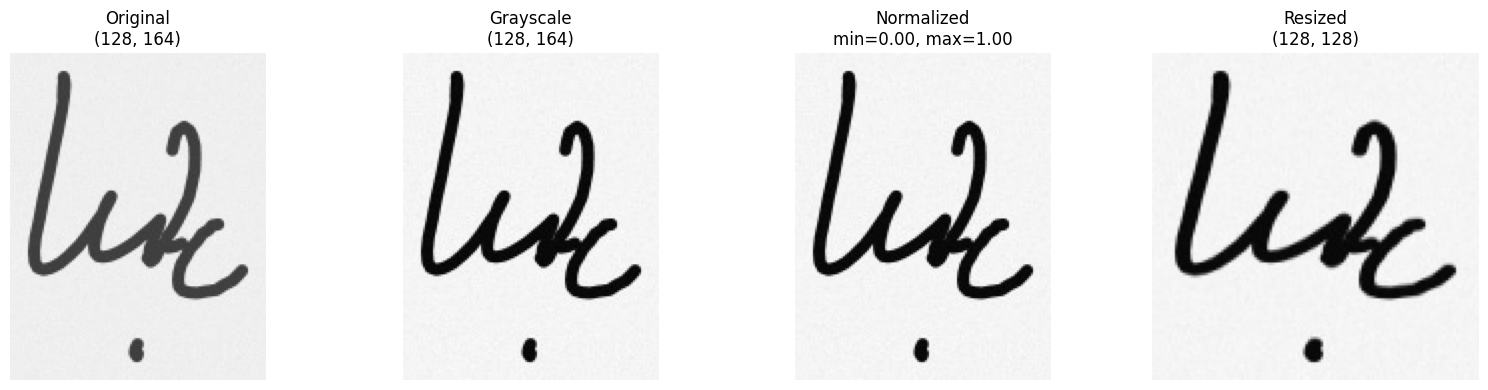

In [8]:
# Test on a few random samples from dataset
print("Testing preprocessing on random samples...\n")
import random

indices = random.sample(range(len(dataset)), 3)

for idx in indices:
    sample = dataset[idx]
    print(f"\nLabel: '{sample['text']}'")
    preprocessed = preprocess_image(
        sample["image"], target_size=(128, 128), show_steps=True
    )

## Apply Preprocessing to Dataset

In [9]:
TARGET_SIZE = (128, 128)  # (width, height) - có thể điều chỉnh


def preprocess_batch(examples):
    """Apply preprocessing to a batch of images"""
    preprocessed_images = []

    for image in examples["image"]:
        # Preprocess
        processed = preprocess_image(image, target_size=TARGET_SIZE, show_steps=False)

        # Convert back to PIL Image (scale to 0-255)
        img_pil = Image.fromarray((processed * 255).astype(np.uint8), mode="L")
        preprocessed_images.append(img_pil)

    return {"image": preprocessed_images}


# Apply preprocessing using map
print(f"Applying preprocessing (target size: {TARGET_SIZE})...")
preprocessed_dataset = dataset.map(
    preprocess_batch, batched=True, batch_size=100, desc="Preprocessing"
)

print("\nPreprocessed dataset:")
print(preprocessed_dataset)
print(f"\nSample after preprocessing:")
print(f"  - Label: {preprocessed_dataset[0]['text']}")
print(f"  - Image size: {preprocessed_dataset[0]['image'].size}")
print(f"  - Image mode: {preprocessed_dataset[0]['image'].mode}")

Applying preprocessing (target size: (128, 128))...


Preprocessing:   0%|          | 0/110488 [00:00<?, ? examples/s]


Preprocessed dataset:
Dataset({
    features: ['image', 'text'],
    num_rows: 110488
})

Sample after preprocessing:
  - Label: Số
  - Image size: (128, 128)
  - Image mode: L


## Visualize Preprocessed Results

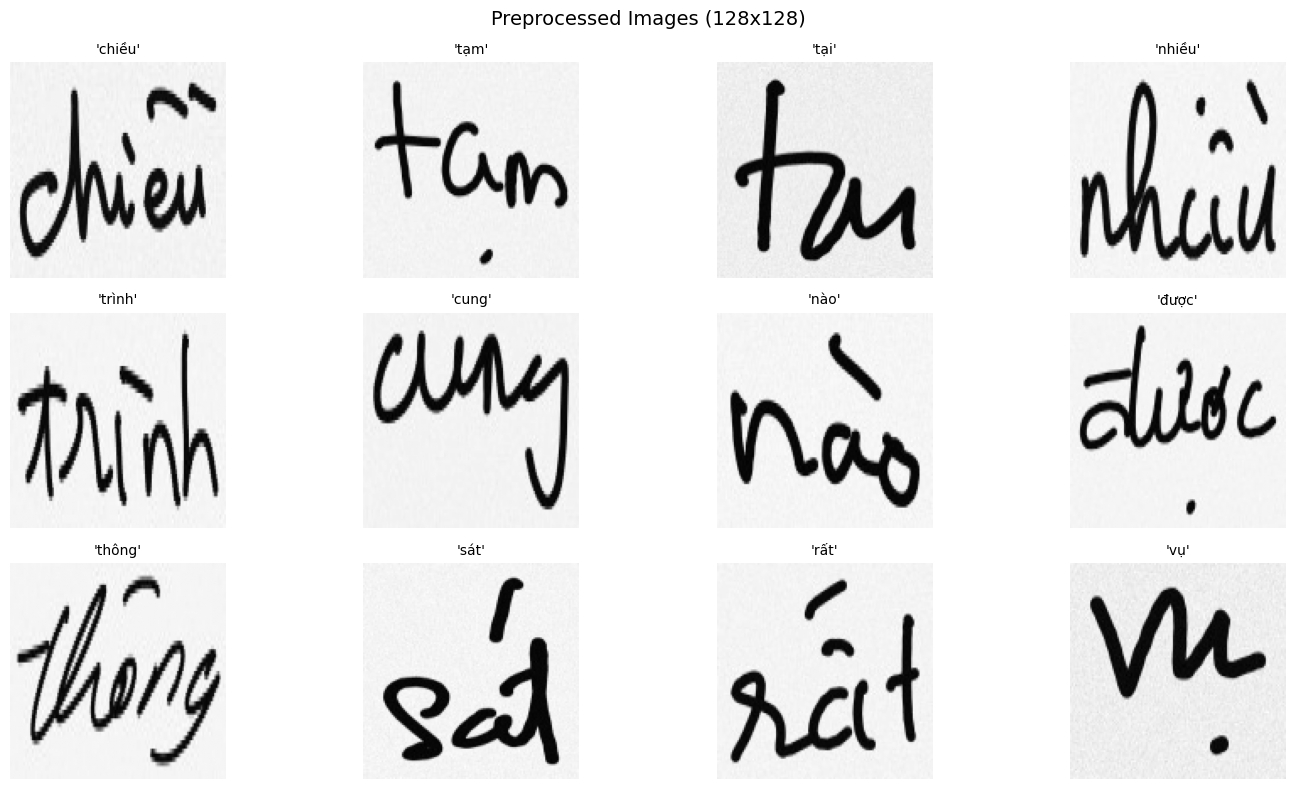

In [10]:
# Visualize some preprocessed samples
fig, axes = plt.subplots(3, 4, figsize=(15, 8))
axes = axes.flatten()

indices = random.sample(range(len(preprocessed_dataset)), 12)

for idx, ax in zip(indices, axes):
    sample = preprocessed_dataset[idx]
    ax.imshow(sample["image"], cmap="gray")
    ax.set_title(f"'{sample['text']}'", fontsize=10)
    ax.axis("off")

plt.suptitle(f"Preprocessed Images ({TARGET_SIZE[0]}x{TARGET_SIZE[1]})", fontsize=14)
plt.tight_layout()
plt.show()

## Save Preprocessed Dataset

In [11]:
# Save preprocessed dataset
output_path = "../data/hwdb_word_preprocessed"
preprocessed_dataset.save_to_disk(output_path)
print(f"Saved preprocessed dataset to: {output_path}")

# Or push to HuggingFace Hub
# preprocessed_dataset.push_to_hub("your-username/uit-hwdb-word-preprocessed")

Saving the dataset (0/2 shards):   0%|          | 0/110488 [00:00<?, ? examples/s]

Saved preprocessed dataset to: ../data/hwdb_word_preprocessed
